# BIND — TNG300-1-Dark painted box (snapshot 099)

Inspect the two-stage paint of the full IllustrisTNG_DM box (205 Mpc/h, 2500³ DM particles):

- **Stage 1** (`run_paint_tng_project.sh`, CPU/MPI): stream-project DMO into z-slabs, find halos, extract per-halo cutouts → `stage1/stage1_slab*.npz`.
- **Stage 2** (`run_paint_tng_generate.sh`, GPU): flow-matching generation + composite → `composite_slab*.npz`.

This notebook sanity-checks stage 1 and visualizes both stages. Stage-2 cells populate once the composites are written.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# --- config: point at the paint output directory ---
RUN_DIR = Path("/mnt/home/mlee1/ceph/bind_illustristng/snap_099")
STAGE1 = RUN_DIR / "stage1"

man = json.loads((STAGE1 / "stage1_manifest.json").read_text())
BOX, NPIX, NSLAB = man["box_size"], man["npix"], man["n_slabs"]
PMASS = man["particle_mass"]
print(f"box={BOX} Mpc/h  npix={NPIX}  n_slabs={NSLAB}  "
      f"n_halos={man['n_halos']}  pmass={PMASS:.3e} Msun/h")


def block_downsample(a, target=700):
    """Area-average a 2D map down to ~target px for fast display."""
    n = a.shape[0]
    f = max(1, n // target)
    m = (n // f) * f
    return a[:m, :m].reshape(m // f, f, m // f, f).mean(axis=(1, 3))

box=205.0 Mpc/h  npix=4198  n_slabs=4  n_halos=2951  pmass=4.727e+07 Msun/h


## 1. Stage-1 physics sanity checks

Mass conservation (the streaming MPI projection must equal `pmass × N`), implied Ωm,
halo mass range, R200↔M200c consistency, and that cutouts are centered on density peaks.

In [2]:
RHO_CRIT = 2.775e11   # (Msun/h) / (Mpc/h)^3
N_PART = 2500**3      # TNG300-1-Dark

tot = 0.0
masses, r200s, peak = [], [], []
for si in range(NSLAB):
    d = np.load(STAGE1 / f"stage1_slab{si:02d}.npz")
    tot += d["dmo"].sum()
    if int(d["n_halos"]):
        masses.append(d["halo_masses"]); r200s.append(d["halo_r200"])
        cond = d["condition"]
        cen = cond[:, 48:80, 48:80].mean(axis=(1, 2))
        peak.append(cen > cond.mean(axis=(1, 2)))
masses = np.concatenate(masses); r200s = np.concatenate(r200s); peak = np.concatenate(peak)

print(f"mass conservation : projected={tot:.4e}  expected pmass*N={PMASS*N_PART:.4e}  "
      f"ratio={tot/(PMASS*N_PART):.4f}")
print(f"Omega_m from maps : {tot/(RHO_CRIT*BOX**3):.4f}  (TNG fiducial 0.3089)")
print(f"halos             : {len(masses)}  M200c {masses.min():.2e}..{masses.max():.2e} Msun/h  "
      f"(>1e14: {(masses>1e14).sum()})")
Rcheck = (masses / (4/3 * np.pi * 200 * RHO_CRIT))**(1/3)
print(f"R200 vs M200c     : median catalog={np.median(r200s):.3f}  analytic={np.median(Rcheck):.3f} Mpc/h")
print(f"cutout centering  : {100*peak.mean():.0f}% of halos have central density > patch mean")

mass conservation : projected=7.3862e+17  expected pmass*N=7.3862e+17  ratio=1.0000
Omega_m from maps : 0.3090  (TNG fiducial 0.3089)
halos             : 2951  M200c 1.00e+13..1.02e+15 Msun/h  (>1e14: 154)
R200 vs M200c     : median catalog=0.431  analytic=0.431 Mpc/h
cutout centering  : 99% of halos have central density > patch mean


## 2. DMO cosmic web + halo positions

One z-slab of the DMO projection (log density), with the mass-cut halos overplotted
(circle size ∝ log M200c). Halos should sit on the bright nodes of the web.

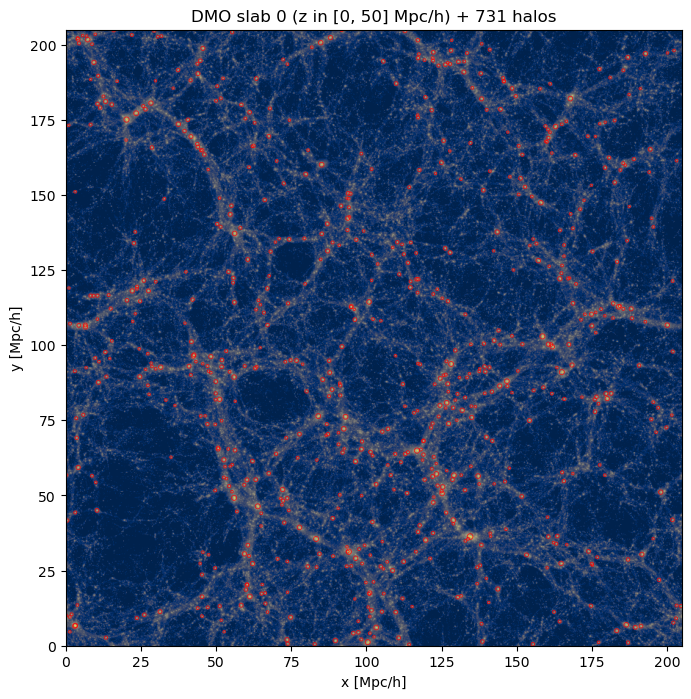

In [3]:
SLAB = 0
d = np.load(STAGE1 / f"stage1_slab{SLAB:02d}.npz")
disp = block_downsample(d["dmo"])
ctr, mass = d["halo_centers"], d["halo_masses"]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(disp.T, origin="lower", extent=[0, BOX, 0, BOX],
          norm=LogNorm(vmin=np.percentile(disp, 20), vmax=disp.max()), cmap="cividis")
ax.scatter(ctr[:, 0], ctr[:, 1], s=8*(np.log10(mass)-13)+3,
           facecolors="none", edgecolors="red", lw=0.6, alpha=0.8)
ax.set(xlabel="x [Mpc/h]", ylabel="y [Mpc/h]",
       title=f"DMO slab {SLAB} (z in [{SLAB*50}, {(SLAB+1)*50}] Mpc/h) + {len(mass)} halos")
plt.show()

## 3. Halo mass function

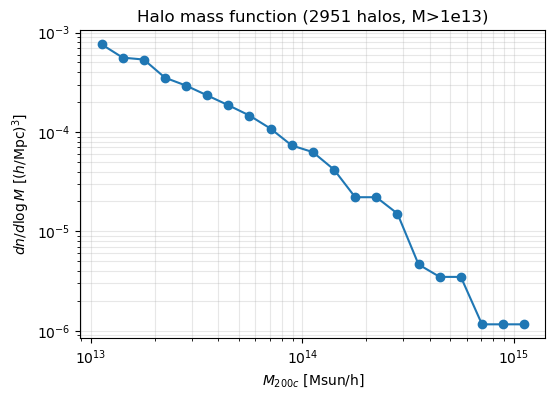

In [4]:
b = np.logspace(13, 15.1, 22)
cen = np.sqrt(b[1:] * b[:-1]); dlogM = np.diff(np.log10(b))
h, _ = np.histogram(masses, bins=b)

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(cen, h / BOX**3 / dlogM, "o-")
ax.set(xlabel=r"$M_{200c}$ [Msun/h]", ylabel=r"$dn/d\log M\ [(h/{\rm Mpc})^3]$",
       title=f"Halo mass function ({len(masses)} halos, M>1e13)")
ax.grid(alpha=0.3, which="both")
plt.show()

## 4. Multiscale DMO context (the network inputs)

The 4 channels the model conditions on, at the **fixed physical scales** 6.25 / 12.5 / 25 / 50 Mpc/h
— all 128². The largest is a 50 Mpc/h window (matching the training data), **not** the full 205 Mpc/h box.

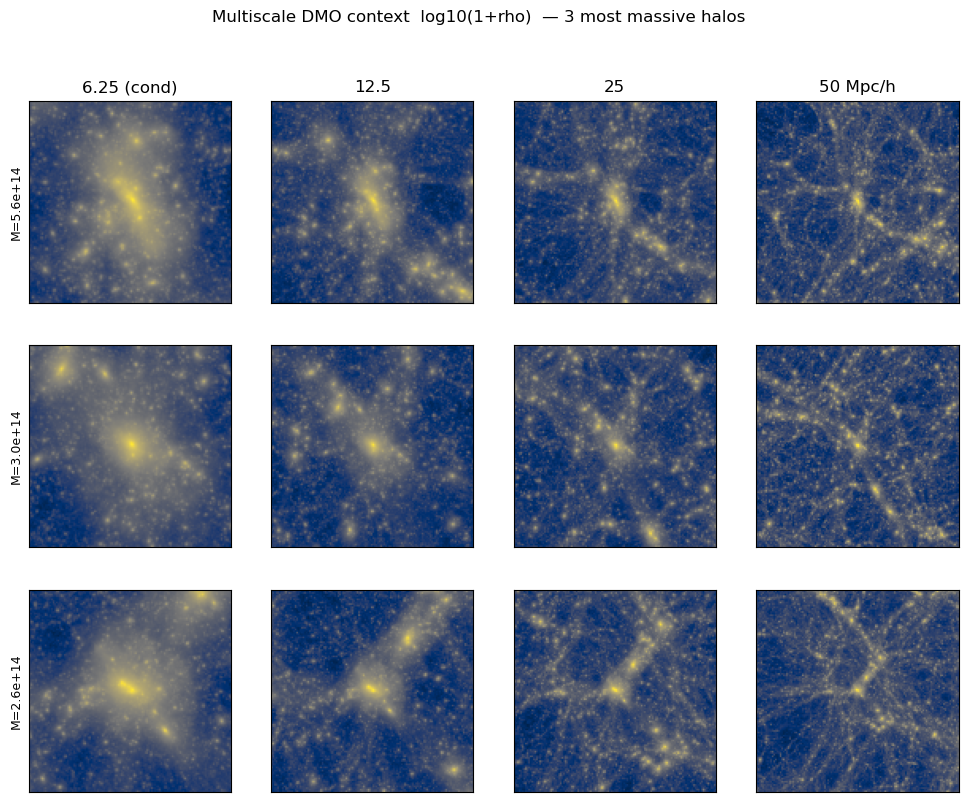

In [5]:
cond, ls = d["condition"], d["large_scale"]
top = np.argsort(mass)[-3:][::-1]
scales = ["6.25 (cond)", "12.5", "25", "50 Mpc/h"]

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for row, hi in enumerate(top):
    chans = [cond[hi]] + [ls[hi, k] for k in range(3)]
    for col, (c, nm) in enumerate(zip(chans, scales)):
        ax = axes[row, col]
        ax.imshow(np.log10(c + 1), origin="lower", cmap="cividis")
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0: ax.set_title(nm)
        if col == 0: ax.set_ylabel(f"M={mass[hi]:.1e}", fontsize=9)
fig.suptitle("Multiscale DMO context  log10(1+rho)  — 3 most massive halos")
plt.show()

## 5. Stage-2 painted hydro fields

The cells below populate once `composite_slab*.npz` are written. Each holds the per-slab
`composite` = [DM_hydro, Gas, Stars] (3, npix, npix) plus the input `dmo`.

In [6]:
def safe_load(f):
    """Load a composite npz, returning None if it's still being written."""
    try:
        d = np.load(f); _ = d["composite"].shape
        return d
    except Exception:
        return None

comp_files = [f for f in sorted(RUN_DIR.glob("composite_slab*.npz")) if safe_load(f) is not None]
print(f"{len(comp_files)} / {NSLAB} composites readable")
summ = RUN_DIR / "summary.json"
if summ.exists():
    s = json.loads(summ.read_text())
    print("model:", s["model"])
    for ps in s["per_slab"]:
        print("  slab", ps["slab_idx"], ps)

4 / 4 composites readable
model: Model(n_params=35, no_large_scale=False, predict_thermo=False, device=cuda)
  slab 0 {'slab_idx': 0, 'n_halos': 731, 'coverage_pct': 39.49816957234337, 'scale_global': 0.9999470114707947}
  slab 1 {'slab_idx': 1, 'n_halos': 700, 'coverage_pct': 38.33058392787146, 'scale_global': 1.000100016593933}
  slab 2 {'slab_idx': 2, 'n_halos': 755, 'coverage_pct': 41.1135171561312, 'scale_global': 0.9999070167541504}
  slab 3 {'slab_idx': 3, 'n_halos': 765, 'coverage_pct': 41.75157366390357, 'scale_global': 0.9999821186065674}


### Full-box: DMO vs painted [DM_hydro, Gas, Stars]

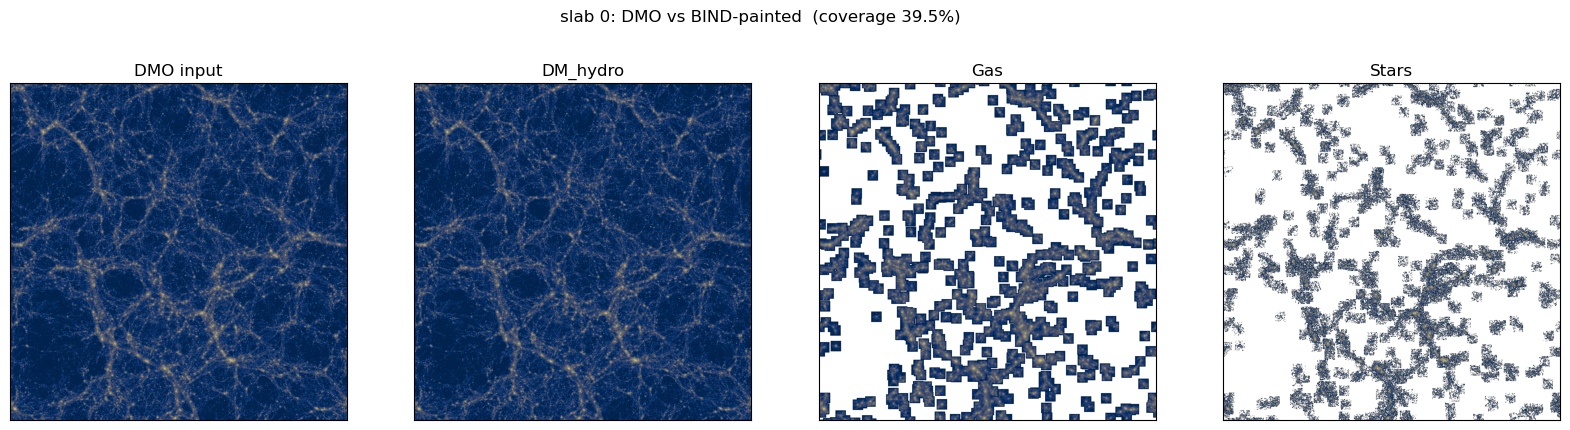

In [7]:
if comp_files:
    c = np.load(comp_files[0]); comp, dmo = c["composite"], c["dmo"]
    fields = [("DMO input", dmo), ("DM_hydro", comp[0]), ("Gas", comp[1]), ("Stars", comp[2])]
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for ax, (t, f) in zip(axes, fields):
        dd = block_downsample(f)
        vmin = np.percentile(dd[dd > 0], 20) if (dd > 0).any() else 1.0
        ax.imshow(dd.T, origin="lower", extent=[0, BOX, 0, BOX],
                  norm=LogNorm(vmin=vmin, vmax=dd.max() + 1), cmap="cividis")
        ax.set_title(t); ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"slab {int(c['slab_idx'])}: DMO vs BIND-painted  "
                 f"(coverage {float(c['coverage_pct']):.1f}%)")
    plt.show()
else:
    print("No composites yet — re-run this cell once stage 2 has written one.")

### Zoom on the most massive painted halo (±4 Mpc/h)

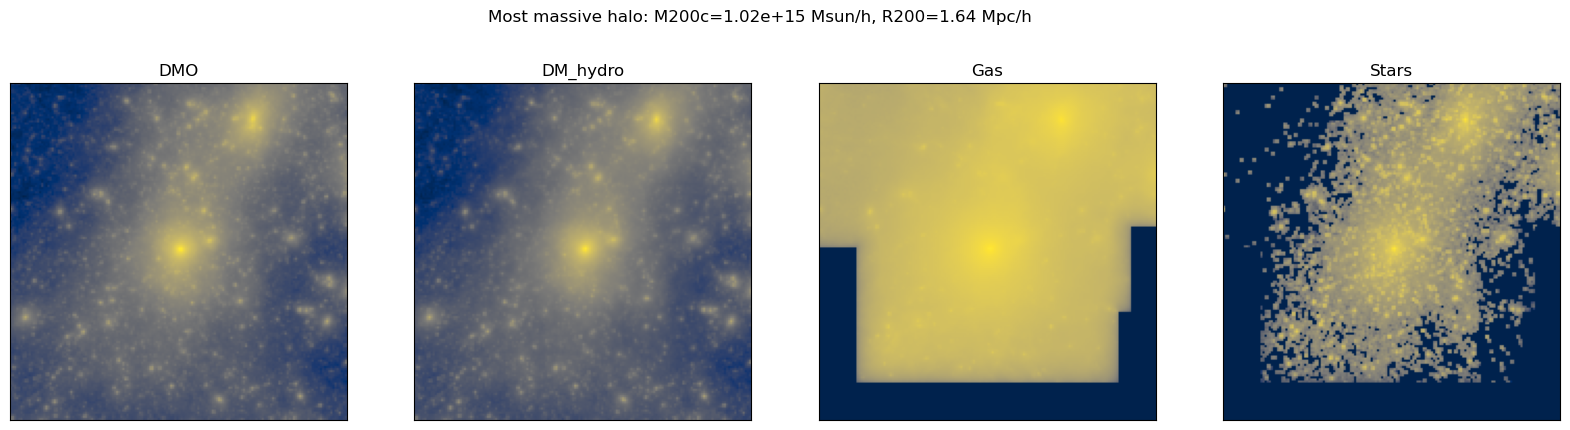

In [8]:
if comp_files:
    best = None
    for f in comp_files:
        cc = np.load(f); i = cc["halo_masses"].argmax()
        if best is None or cc["halo_masses"][i] > best[2]:
            best = (f, cc["halo_centers"][i], float(cc["halo_masses"][i]), float(cc["halo_r200"][i]))
    f, center, M, r200 = best
    cc = np.load(f); comp, dmo = cc["composite"], cc["dmo"]
    ppm = NPIX / BOX
    cx, cy = int(center[0]*ppm) % NPIX, int(center[1]*ppm) % NPIX
    half = int(4 * ppm)
    win = lambda A: np.take(np.take(A, np.arange(cx-half, cx+half), axis=0, mode="wrap"),
                            np.arange(cy-half, cy+half), axis=1, mode="wrap")
    panels = [("DMO", dmo), ("DM_hydro", comp[0]), ("Gas", comp[1]), ("Stars", comp[2])]
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for ax, (t, A) in zip(axes, panels):
        w = win(A)
        ax.imshow(np.log10(w.T + 1), origin="lower", cmap="cividis")
        ax.set_title(t); ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"Most massive halo: M200c={M:.2e} Msun/h, R200={r200:.2f} Mpc/h")
    plt.show()
else:
    print("No composites yet.")

### Stage-2 mass conservation
The BIND composite is renormalized so the total mass per slab matches the DMO input.

In [9]:
for f in comp_files:
    cc = np.load(f); dmo, comp = cc["dmo"], cc["composite"]
    print(f"slab {int(cc['slab_idx'])}: DMO={dmo.sum():.4e}  composite={comp.sum():.4e}  "
          f"ratio={comp.sum()/dmo.sum():.4f}  coverage={float(cc['coverage_pct']):.1f}%  "
          f"n_halos={int(cc['n_halos'])}")

slab 0: DMO=1.7635e+17  composite=1.7635e+17  ratio=1.0000  coverage=39.5%  n_halos=731


slab 1: DMO=1.7945e+17  composite=1.7945e+17  ratio=1.0000  coverage=38.3%  n_halos=700


slab 2: DMO=1.8879e+17  composite=1.8879e+17  ratio=1.0000  coverage=41.1%  n_halos=755


slab 3: DMO=1.9402e+17  composite=1.9403e+17  ratio=1.0000  coverage=41.8%  n_halos=765


## 6. Re-composite the SAME generated halos with different blends (no GPU)

The flow-matching sampler (stage 2) is the expensive step, and its per-halo output is
already saved (`generated_patches` in each `composite_slab*.npz`). `recomposite_slab`
re-runs **only** the compositing — reusing those patches + the stage-1 cutouts — so you
can sweep blend settings interactively without ever touching the GPU:

- `r200_factor=0` → square Hann taper (the stage-2 default)
- `r200_factor=k` → circular paste confined to *k·R200c*
- `taper_frac`, `patch_mass_match` → edge softness / per-halo mass matching

Same settings reproduce the saved composite exactly; below we vary the aperture and
look at the Gas channel around the most massive cluster.

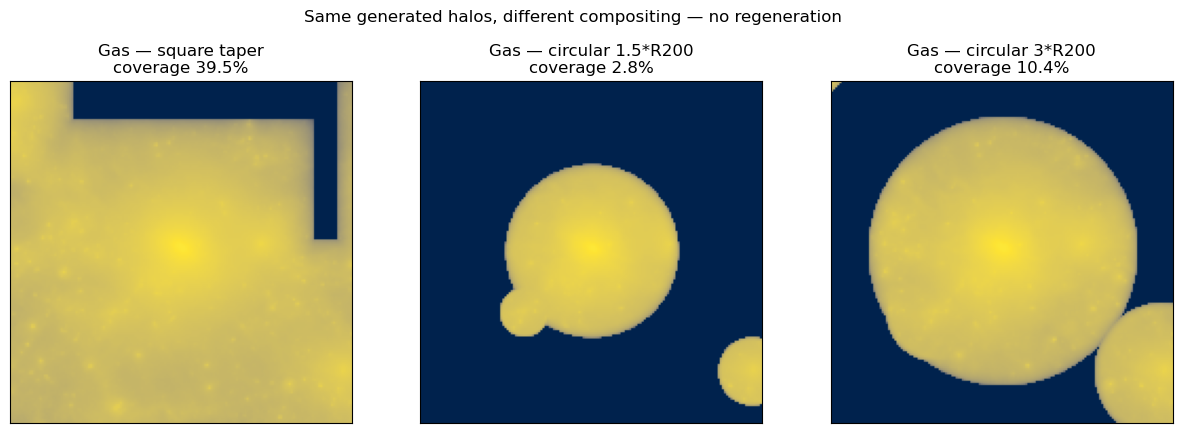

In [10]:
from bind.inference.paint_stages import recomposite_slab

SLAB_RC = 0
s1 = STAGE1 / f"stage1_slab{SLAB_RC:02d}.npz"
gp = RUN_DIR / f"composite_slab{SLAB_RC:02d}.npz"

settings = [
    ("square taper",      dict(r200_factor=0.0, taper_frac=0.15)),
    ("circular 1.5*R200", dict(r200_factor=1.5)),
    ("circular 3*R200",   dict(r200_factor=3.0)),
]

sd = np.load(s1)
i = sd["halo_masses"].argmax(); center = sd["halo_centers"][i]
ppm = NPIX / BOX
cx, cy = int(center[0]*ppm) % NPIX, int(center[1]*ppm) % NPIX
half = int(4 * ppm)
win = lambda A: np.take(np.take(A, np.arange(cx-half, cx+half), axis=0, mode="wrap"),
                        np.arange(cy-half, cy+half), axis=1, mode="wrap")

fig, axes = plt.subplots(1, len(settings), figsize=(5*len(settings), 5))
for ax, (name, kw) in zip(axes, settings):
    bundle = recomposite_slab(s1, gp, **kw)        # <-- no GPU, reuses saved patches
    gas = win(bundle["composite"][1])
    ax.imshow(np.log10(gas.T + 1), origin="lower", cmap="cividis")
    ax.set_title(f"Gas — {name}\ncoverage {bundle['coverage_pct']:.1f}%")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Same generated halos, different compositing — no regeneration")
plt.show()

To write a full re-composited box to disk (all slabs, new settings), use the batch
helper or the CLI — both reuse the saved patches, no GPU:

```python
from bind.inference.paint_stages import recomposite_from_saved
recomposite_from_saved(STAGE1, RUN_DIR, RUN_DIR.parent / "snap_099_r200paste", r200_factor=2.0)
```
```bash
bind-paint-recomposite --stage1_dir <stage1> --generated_dir <stage2_out> \
    --output_dir <new_dir> --r200_factor 2.0
```

## 7. Matter power spectrum suppression  $S(k) = P_{\rm hydro}(k)/P_{\rm DMO}(k)$

The slab maps are **masses**, so summing the z-slabs gives the full-box column-density
field. The total painted matter is `DM_hydro + Gas + Stars` (mass-matched to the DMO
input per slab, so $S \to 1$ as $k \to 0$). The 2D $P(k)$ ratio is the baryonic
suppression — line-of-sight projection effects cancel because both fields are projected
identically. We cap at the Nyquist wavenumber ($k_{\rm Nyq}=\pi\,N_{\rm pix}/L$); the
$k$-space corners beyond it are noisy.

*Caveat:* only halos with $M_{200c}>10^{13}$ were painted, so this is the suppression
from that population (the dominant contribution at these scales, but it misses small,
low-mass halos).

full-box mass: DMO=7.3862e+17  painted=7.3862e+17  ratio=1.0000

Computing power spectrum of the field...


Time to complete loop = 0.13
Time taken = 0.85 seconds

Computing power spectrum of the field...


Time to complete loop = 0.13
Time taken = 0.57 seconds


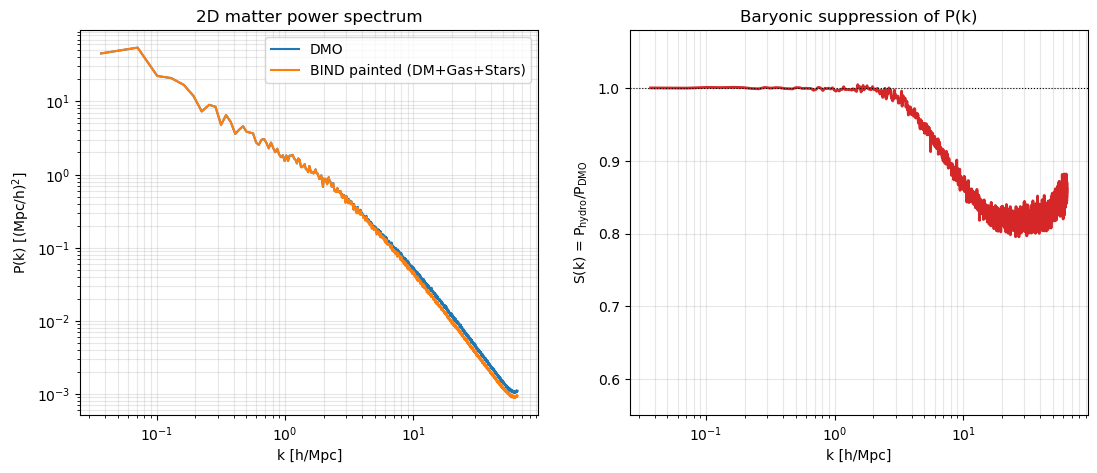

S(k=  1.0 h/Mpc) = 0.998
S(k=  5.0 h/Mpc) = 0.938
S(k= 10.0 h/Mpc) = 0.873
S(k= 20.0 h/Mpc) = 0.833
S(k= 40.0 h/Mpc) = 0.829


In [11]:
from bind.metrics import power_spectrum_2d

# Sum z-slabs -> full-box grids (masses are additive)
dmo_full = painted_full = None
for si in range(NSLAB):
    cc = np.load(RUN_DIR / f"composite_slab{si:02d}.npz")
    dmo_s = cc["dmo"]
    total_s = cc["composite"].sum(axis=0)          # DM_hydro + Gas + Stars
    dmo_full = dmo_s.copy() if dmo_full is None else dmo_full + dmo_s
    painted_full = total_s.copy() if painted_full is None else painted_full + total_s
print(f"full-box mass: DMO={dmo_full.sum():.4e}  painted={painted_full.sum():.4e}  "
      f"ratio={painted_full.sum()/dmo_full.sum():.4f}")

k, P_dmo = power_spectrum_2d(dmo_full, box_size=BOX)
_, P_bind = power_spectrum_2d(painted_full, box_size=BOX)
S = P_bind / P_dmo
k_nyq = np.pi * NPIX / BOX
m = k <= k_nyq

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
a1.loglog(k[m], P_dmo[m], label="DMO")
a1.loglog(k[m], P_bind[m], label="BIND painted (DM+Gas+Stars)")
a1.set(xlabel="k [h/Mpc]", ylabel=r"P(k) [(Mpc/h)$^2$]", title="2D matter power spectrum")
a1.legend(); a1.grid(alpha=0.3, which="both")
a2.semilogx(k[m], S[m], lw=2, color="C3"); a2.axhline(1, color="k", ls=":", lw=0.8)
a2.set(xlabel="k [h/Mpc]", ylabel=r"S(k) = P$_{\rm hydro}$/P$_{\rm DMO}$",
       title="Baryonic suppression of P(k)", ylim=(0.55, 1.08))
a2.grid(alpha=0.3, which="both")
plt.show()

for kk in [1, 5, 10, 20, 40]:
    j = np.argmin(np.abs(k - kk)); print(f"S(k={k[j]:5.1f} h/Mpc) = {S[j]:.3f}")